![](img/NetworkX.jpg)

## Network Analysis with NetworkX
----

This notebook is based on: https://github.com/rossanoventurini/adsds/blob/main/Lab/Lecture_08/L08_Graphs_with_NetworkX_no_sols.ipynb

---

### Overview

[NetworkX](https://networkx.github.io/) is a Python package for the creation, manipulation, and study of the structure, dynamics, and functions of complex networks.

- Data structures for graphs, digraphs, and multigraphs
- Many standard graph algorithms
- Network structure and analysis measures
- Generators for classic graphs, random graphs, and synthetic networks
- Nodes can be "anything" (e.g., text, images, XML records)
- Edges can hold arbitrary data (e.g., weights, time-series)

---

### Get prepared

#### Installations

tbd

#### Imports

In [ ]:
import networkx as nx
print(nx.__version__)
import matplotlib.pyplot as plt
import numpy 

3.5


---

### Functions to plot graphs 

In [ ]:
def plot_graph(G, size=5):
    plt.figure(figsize=(size, size))
    nx.draw(G, with_labels=True, node_color='skyblue', width=.3, font_size=8)
    plt.show()

def plot_graph_with_weights(G):
    pos = nx.planar_layout(G) # pos = nx.nx_agraph.graphviz_layout(G)
    nx.draw_networkx(G,pos)
    labels = nx.get_edge_attributes(G,'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
    plt.show()

---

### Basic graph construction

#### In advance

In Python, a node is a tuple of the form `(n, node_attribute_dict)`.

Similar are edges: `(n1, n2, edge_attribute_dict)`

#### Create a Graph

A graph is a __collection of nodes and edges__, *i.e.*, G = (V, E). Let us create an empty graph

Let's start by creating an empty undirected graph

In [ ]:
G = nx.Graph()

The graph object has some __properties__ and __methods__ giving data about the whole graph, see below.

#### Populate the graph.


 We can add one node at time using the `add-node` method or add any iterable collections (lists, strings etc..) with the `G.add_nodes_from` method. 

We are now using strings as nodes's names, but nodes can be any hashable object.

In [ ]:
G.add_node('a')
my_list = ['b', 'c', 'd']
G.add_nodes_from(my_list)

We can __inspect the nodes__ in a graph using *G.nodes()*.

In [ ]:
G.nodes()
list(G.nodes())

['a', 'b', 'c', 'd']

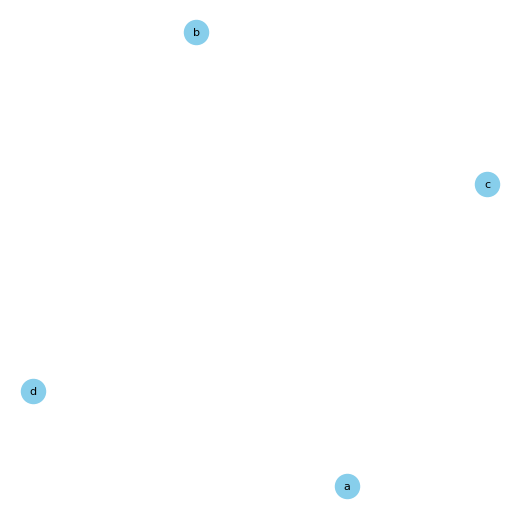

In [ ]:
plot_graph(G)

Now let us _add edges to the graph. 

We can add one edge at time with *G.add_edge()*, specifying the nodes between whom we want the edge to stay. As for nodes, we can pass an iterable colletion to *G.add_edges_from()*.

In [ ]:
G.add_edges_from([('a', 'b'), ('a', 'c'), ('c', 'd'), ('b', 'd')])
G.edges()
list(G.edges())

[('a', 'b'), ('a', 'c'), ('b', 'd'), ('c', 'd')]

If we add edges between nodes that do not exist, __theses nodes are automatically added__

In [ ]:
G.add_edge("a", "e")
G.add_edge("a", "b")

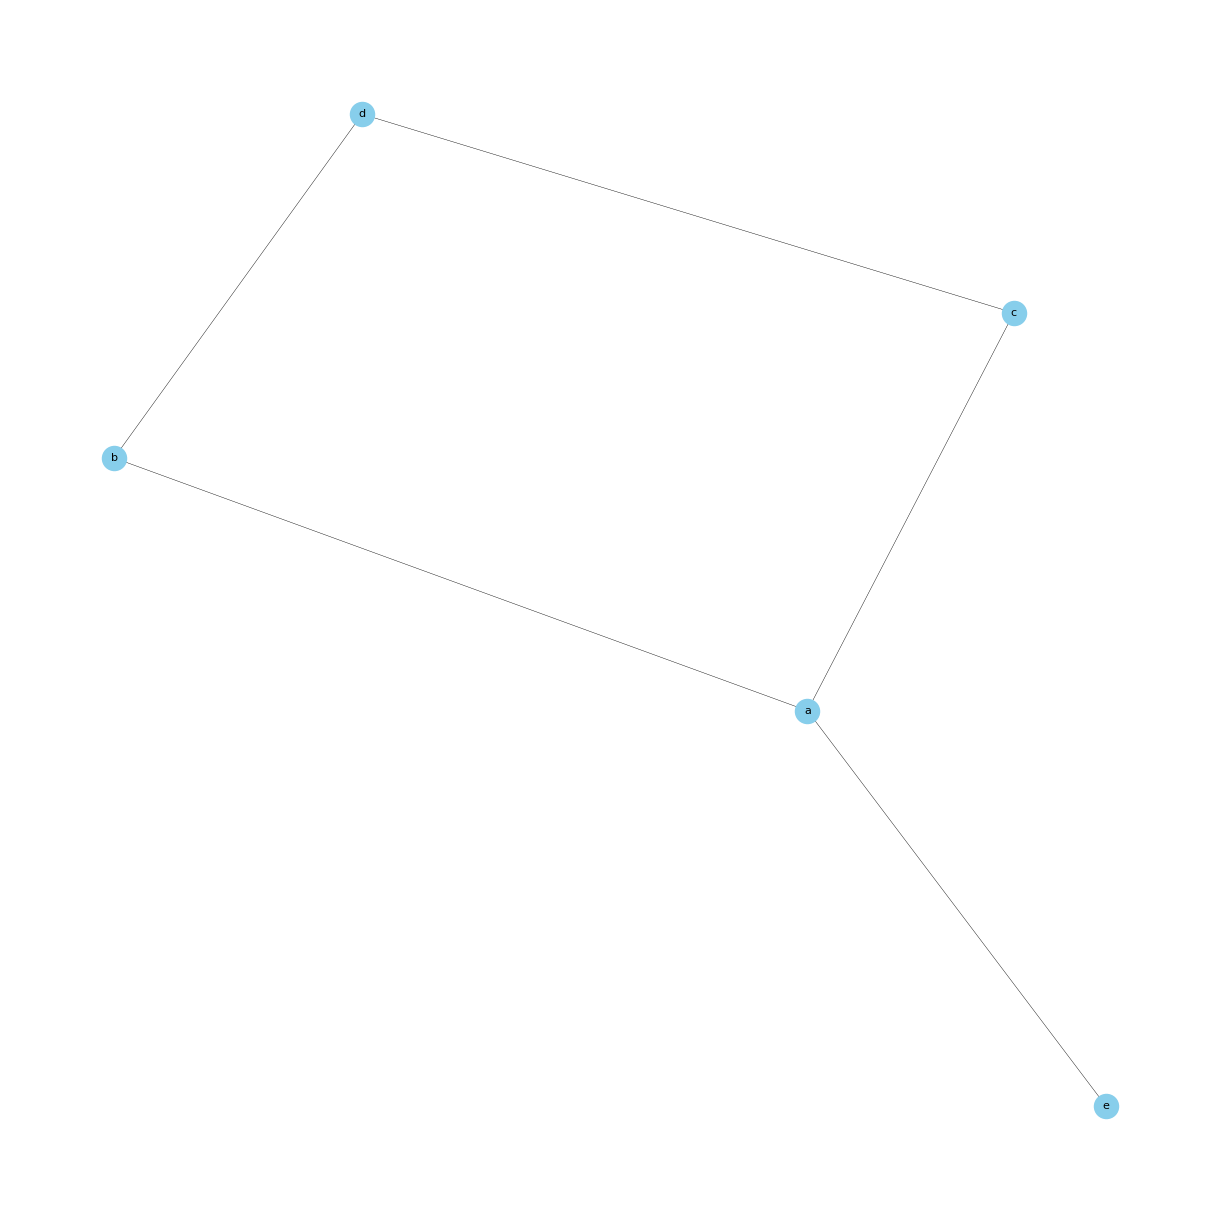

In [ ]:
plot_graph(G, 12)

__Remove__ nodes using the *G.remove_node()* or the *G.remove_nodes_from()*

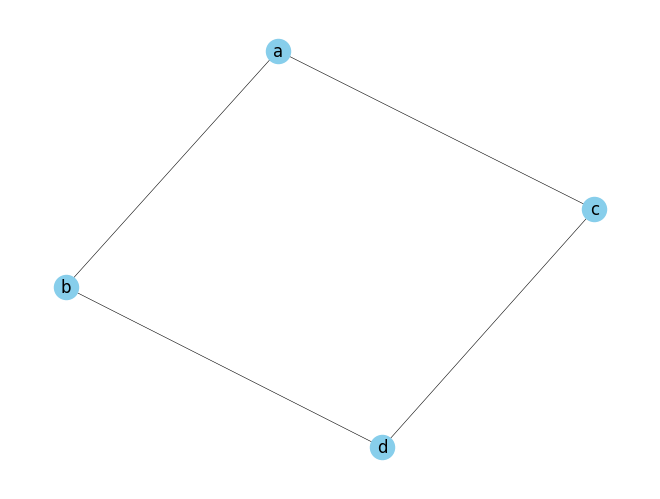

In [ ]:
G.remove_node('e')
plot_graph(G)

---

## Properties

#### Graph properties

In [ ]:
# Number of nodes
print("Number of Nodes: ", G.order()) # equivalent to len(G) and G.number_of_nodes()
# Number of edges
print("Number of Edges: ", G.number_of_edges())

Number of Nodes:  4
Number of Edges:  4


#### Node properties

In [ ]:
for node in G.nodes:
    G.nodes[node]['color'] = 'white'

In [ ]:
list(G.nodes(data=True))

[('a', {'color': 'white'}),
 ('b', {'color': 'white'}),
 ('c', {'color': 'white'}),
 ('d', {'color': 'white'})]

In [ ]:
G.nodes['a']['color']

'white'

#### Edge properties.

In [ ]:
G['a']['b']['color'] = 'green'
G['a']['c']['color'] = 'black'
list(G.edges(data=True))

[('a', 'b', {'color': 'green'}),
 ('a', 'c', {'color': 'black'}),
 ('b', 'd', {}),
 ('c', 'd', {})]

#### Neighbours and node degree

We can explore the **neighbours** and the **degree** of the nodes in a graph using the facilities *G.adj* and *G.degree*.

In [ ]:
print(G.adj)

{'a': {'b': {'color': 'green'}, 'c': {'color': 'black'}}, 'b': {'a': {'color': 'green'}, 'd': {}}, 'c': {'a': {'color': 'black'}, 'd': {}}, 'd': {'c': {}, 'b': {}}}


Graph are __subscriptable__ objects and we can access neighbours directly with the [ ] operator.

In [ ]:
print(G.adj['a'])
print(G['a'])

{'b': {'color': 'green'}, 'c': {'color': 'black'}}
{'b': {'color': 'green'}, 'c': {'color': 'black'}}


We can use *G.adj* as a dictionary and __iterate__ over it.

In [ ]:
for node, attr in G.adj.items():
    # attr is a dictionary whose keys are node neighbours and whose value, in turn, is a dictionary 
    # reporting 'property:value' of the edge between node and key
    
    print(node, attr) 

a {'b': {'color': 'green'}, 'c': {'color': 'black'}}
b {'a': {'color': 'green'}, 'd': {}}
c {'a': {'color': 'black'}, 'd': {}}
d {'c': {}, 'b': {}}


The degree property reports the number of edges for each node.

In [ ]:
print(G.degree)

[('a', 2), ('b', 2), ('c', 2), ('d', 2)]


We can compute a degree histogram.

In [ ]:
hist = nx.degree_histogram(G)
hist

[0, 0, 4]

---

## Graph Operations

Networkx supports most common graph operations. Some examples are 
<ul>
<li>Union</li>
<li>Intersection</li>
<li>Complement</li>
</ul>

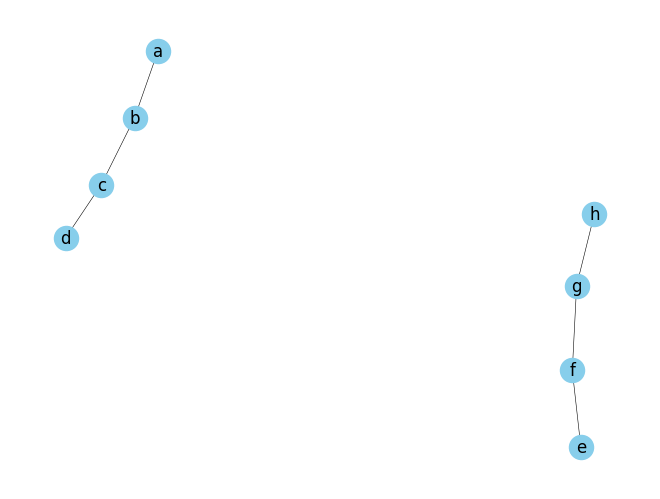

In [ ]:
# Create a first graph G
G = nx.Graph()
G.add_edges_from([("a", "b"), ("b", "c"), ("c", "d")])

# Create a second graph H
H = nx.Graph()
H.add_edges_from([("e", "f"), ("f", "g"), ("g", "h") ])

# Perform the union operation
I = nx.union(G, H)
plot_graph(I)

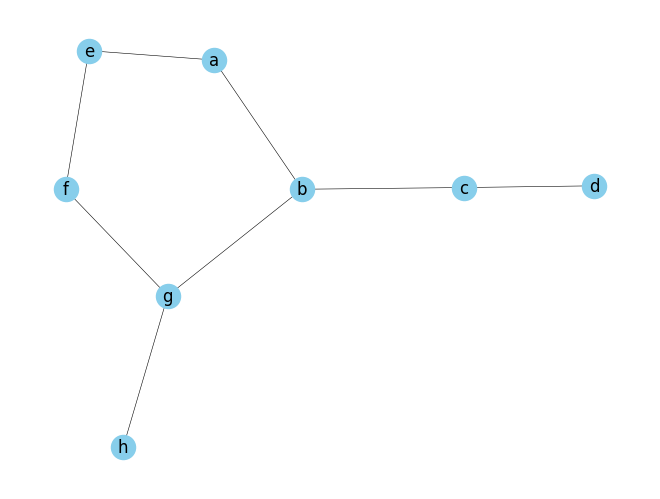

In [ ]:
# Now link the two connected components
I.add_edges_from([("a","e"), ("b", "g")])
plot_graph(I)

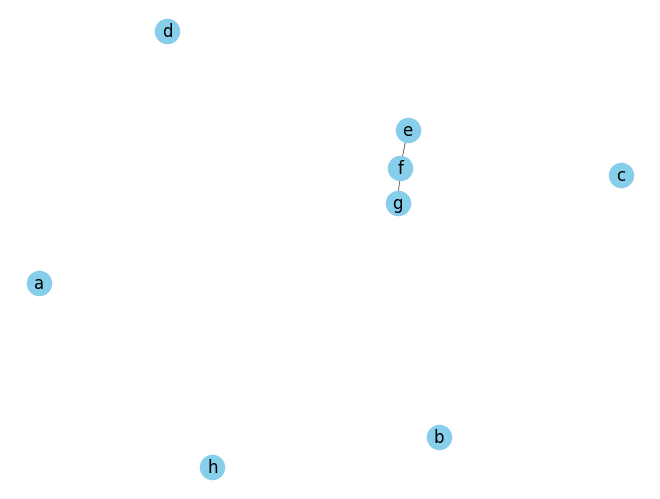

In [ ]:
# Create a third graph
L = nx.Graph()

# To perform intersection between two graphs, they must have the same nodes
# First we copy all the nodes in I into L
L.add_nodes_from(I.nodes())

# Then we add some edge in L
L.add_edges_from([("e", "f"), ("f", "g")])

M = nx.intersection(I, L)

# Only the shared edges between I, L wil survive this operation
plot_graph(M)

---

### Coding Patterns

These are some recommended coding patterns when doing network analysis using NetworkX,
which stem from my personal experience with the package.

#### Iterating over nodes using List Comprehensions
I would recommend that you use the following for compactness: 

```python
[attrs['attr'] for n, attrs in G.nodes(data=True)]
```

And if the node is unimportant, you can do:

```python
[attrs['attr'] for _, attrs in G.nodes(data=True)]
```

#### Iterating over Edges using List Comprehensions

A similar pattern can be used for edges:

```python
[n2 for n1, n2, attrs in G.edges(data=True)]
```

or

```python
[n2 for _, n2, attrs in G.edges(data=True)]
```